In [2]:
import numpy as np
import seaborn as sns
from mytrading import SMABackTester, MomentumBackTester, BollingerBackTester
from itertools import product
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Algoritmi di trading

In [3]:
sma = SMABackTester("EURUSD=X", "1990-01-01", "2025-01-01", (43, 82)) # 43 82 con 43.18% rendimento log
# momentum = MomentumBackTester("EURUSD=X", "1990-01-01", "2025-01-01", 10)
# bollinger = BollingerBackTester("EURUSD=X", "1990-01-01", "2025-01-01", 40, 2)

In [8]:
sma.

Price,Close,High,Low,Open,Volume,LogReturn,CumLogReturn,SMAShort,SMALong,Position,StrategyReturn,CumStrategyReturn
Date,,,,,,,,,,,,
2003-12-02,1.208897,1.210903,1.194600,1.196101,0,0.010307,0.010307,1.208897,1.208897,-1,NaN,NaN
2003-12-03,1.212298,1.213003,1.207700,1.209000,0,0.002809,0.013116,1.210598,1.210598,-1,-0.002809,-0.002809
2003-12-04,1.208094,1.214403,1.204398,1.212004,0,-0.003473,0.009642,1.209763,1.209763,-1,0.003473,0.000665
2003-12-05,1.218695,1.219096,1.206593,1.207802,0,0.008736,0.018379,1.211996,1.211996,-1,-0.008736,-0.008072
2003-12-08,1.222001,1.224005,1.215407,1.216797,0,0.002709,0.021088,1.213997,1.213997,-1,-0.002709,-0.010781
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,1.040258,1.043297,1.040150,1.040258,0,-0.000312,-0.139933,1.059405,1.079552,-1,0.000312,0.432109
2024-12-26,1.039955,1.042535,1.039145,1.039955,0,-0.000291,-0.140224,1.058481,1.078738,-1,0.000291,0.432400
2024-12-27,1.042318,1.044495,1.040669,1.042318,0,0.002270,-0.137955,1.057566,1.077975,-1,-0.002270,0.430130


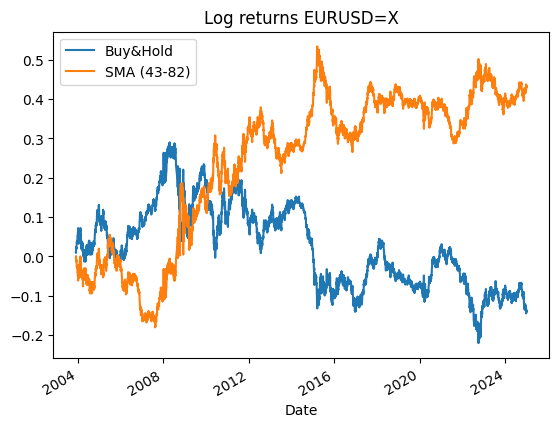

In [4]:
sma.plot_buyhold_return()
sma.plot_strategy_return()
# momentum.plot_strategy_return()
# bollinger.plot_strategy_return()

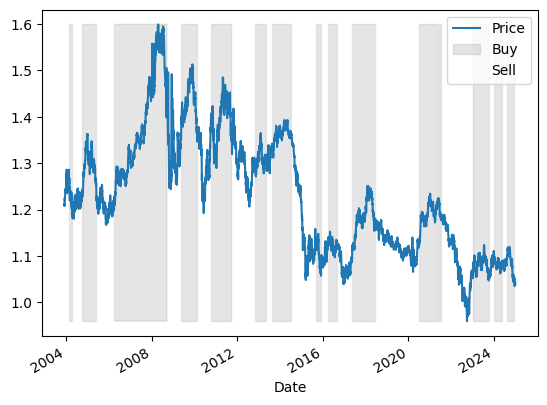

In [18]:
sma.plot_strategy_position()

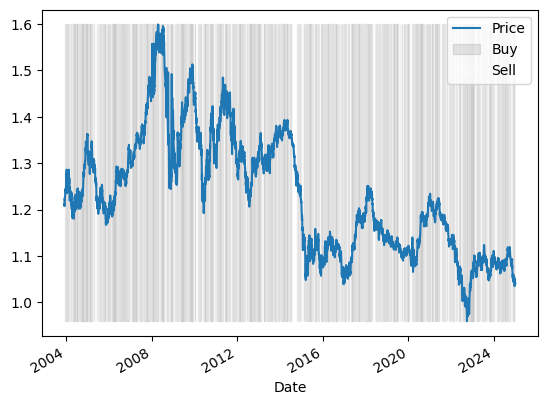

In [17]:
momentum.plot_strategy_position()

In [221]:
combinazioni = list(product(range(40, 101, 1), range(150, 201, 1)))
bktest_comb = []
for comb in combinazioni:
    bktest_comb.append(SMABackTester("EURUSD=X", comb[0], comb[1], "1990-01-01", "2025-01-01"))

In [9]:
import numpy as np
from scipy.optimize import dual_annealing

class Optimizer:
    def __init__(self, func, bounds):
        """
        Inizializza l'oggetto di ottimizzazione.
        :param func: la funzione da ottimizzare
        :param bounds: il range per ciascun argomento (tupla per ogni argomento)
        """
        self.func = func  # Funzione da ottimizzare
        self.bounds = bounds  # Limiti dell'intervallo per ciascun argomento

    def optimize(self):
        """
        Ottimizza la funzione nel range dato usando simulazione di annealing.
        Restituisce il risultato dell'ottimizzazione.
        """
        # Definiamo una funzione che forza l'ottimizzazione a restituire solo valori interi
        def integer_constraint(x):
            return np.round(x).astype(int)

        # Funzione di ottimizzazione con vincoli
        def func_with_integer_constraint(x):
            # Applichiamo il vincolo per forzare variabili intere
            x_int = integer_constraint(x)
            return self.func(x_int)

        # Eseguiamo la simulazione di annealing con bounds e vincoli di interi
        result = dual_annealing(func_with_integer_constraint, self.bounds, seed=42)

        # Risultato dell'ottimizzazione
        if result.success:
            print(f"Funzione ottimizzata. Valore minimo trovato: {result.fun}")
            print(f"Posizione del minimo: {result.x}")
        else:
            print("L'ottimizzazione non è riuscita.")
        
        return result
    
# Funzione di esempio da ottimizzare
def func_to_optimize(x):
    bktest = SMABackTester("EURUSD=X", x[0], x[1], "1990-01-01", "2025-01-01")
    return bktest.get_performance()

# Intervallo di ricerca per ciascun argomento
bounds = [(60, 100), (170, 200)]  # Limiti per x0 e x1

# Creiamo l'oggetto ottimizzatore
optimizer = Optimizer(func_to_optimize, bounds)

optimizer.optimize()

C:\Users\5485\AppData\Local\Temp\ipykernel_15444\2360869799.py:100: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.exp(self._strategy.CumStrategyReturn[-1])
C:\Users\5485\AppData\Local\Temp\ipykernel_15444\2360869799.py:100: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.exp(self._strategy.CumStrategyReturn[-1])
C:\Users\5485\AppData\Local\Temp\ipykernel_15444\2360869799.py:100: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.ilo

Funzione ottimizzata. Valore minimo trovato: 0.8572530742705938
Posizione del minimo: [ 99.16361763 198.52318499]


C:\Users\5485\AppData\Local\Temp\ipykernel_15444\2360869799.py:100: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.exp(self._strategy.CumStrategyReturn[-1])


 message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: 0.8572530742705938
       x: [ 9.916e+01  1.985e+02]
     nit: 1000
    nfev: 4025
    njev: 8
    nhev: 0

C:\Users\5485\AppData\Local\Temp\ipykernel_11484\381454587.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.exp(self._strategy.CumStrategyReturn[-1])


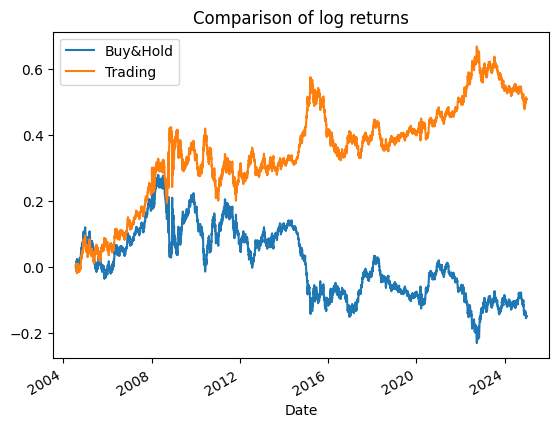

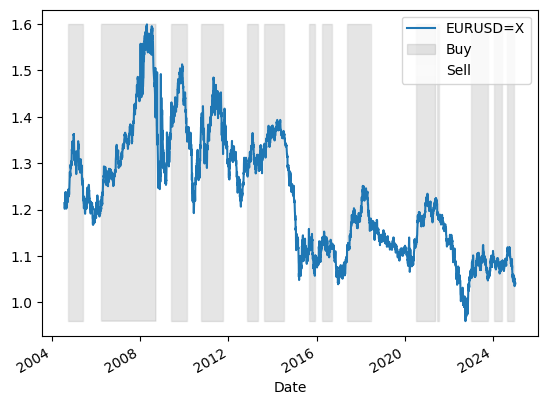

In [222]:
best_strategy = np.argmax([bkc.get_performance() for bkc in bktest_comb])
bktest_comb[best_strategy].plot_returns()
bktest_comb[best_strategy].plot_strategy()

C:\Users\5485\AppData\Local\Temp\ipykernel_11484\381454587.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.exp(self._strategy.CumStrategyReturn[-1])


<Axes: xlabel='Long', ylabel='Short'>

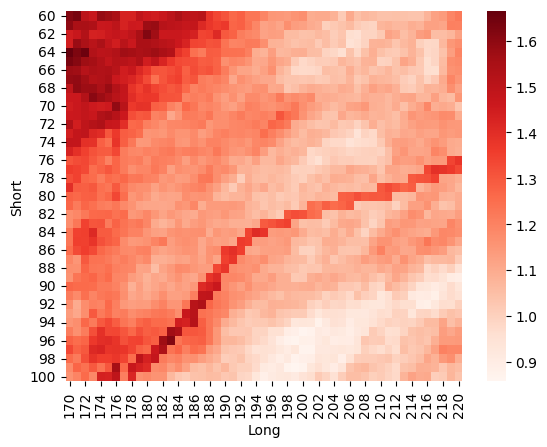

In [223]:
risultati = pd.DataFrame(combinazioni, columns=["Short", "Long"])
risultati["Performance"] = [bkc.get_performance() for bkc in bktest_comb]
heatmap_risultati = risultati.pivot(index="Short", columns="Long", values="Performance")
import seaborn
seaborn.heatmap(heatmap_risultati, cmap="Reds")

In [1]:
import numpy as np
from mytrading import SMABackTester
from ga.evolution import Evolution

def fitness(x, y):
    sma = SMABackTester("EURUSD=X", "1990-01-01", "2025-01-01", x, y)
    return sma.get_performance()

In [25]:
np.random.randint(ind_parameters["lower_bound"], ind_parameters["upper_bound"], 1)[0]

46

In [4]:
ind_parameters = {'lower_bound': 10, 'upper_bound': 100, 'number_of_genes': 2}
pop_parameters = {
    'n_parents': 6,
    'offspring_size':(2, ind_parameters['number_of_genes']),
    'mutation_mean': 1,
    'mutation_sd': 1,
    'size': 10
}

evo = Evolution(pop_parameters, ind_parameters, fitness)
epochs = 10
history = []
x_history = []
y_history = []

for _ in range(epochs):
    print('Epoch {}/{}, Progress: {}%\r'.format(_+1, epochs, np.round(((_+1)/epochs)*100, 2)), end="")
    evo.step()
    history.append(evo._best_score)
    x_history.append(evo._best_individual[0][0])
    y_history.append(evo._best_individual[0][1])

print('\nResults:')
print('Best individual:', evo.solution.best_individual)
print('Fitness value of best individual:', evo.solution.best_score)

c:\Users\5485\Documents\Personale\trading\mytrading.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self._strategy.CumStrategyReturn[-1]
c:\Users\5485\Documents\Personale\trading\mytrading.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self._strategy.CumStrategyReturn[-1]
c:\Users\5485\Documents\Personale\trading\mytrading.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self._strategy.CumStrat

ValueError: window must be an integer 0 or greater

In [6]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from mytrading import TradingBackTester, SMABackTester

# Example of the function f(A, B, t) - you can modify this as needed
def loss_function(sma: TradingBackTester):
    return -sma.get_performance()

param_grid_A = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
param_grid_B = [120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170]
n_splits=5
# smabkt = SMABackTester("EURUSD=X", "1990-01-01", "2025-01-01", (1, 2))

# def k_fold_optimization(t, x_t, param_grid_A, param_grid_B, n_splits=5):
    
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

best_A = None
best_B = None
best_score = np.inf  # Minimize loss function (error)

# Iterate over all combinations of A and B
for Aa in param_grid_A:
    for Bb in param_grid_B:
        fold_errors = []
        sma = SMABackTester("EURUSD=X", "1990-01-01", "2025-01-01", (Aa, Bb))

        # Perform K-fold cross-validation
        for train, test in kf.split(sma._buyhold.index):
            print("TRAIN ", train, "dim= ", len(train))
            print("TEST ", test, "dim= ", len(test))
            train_sma = sma
            train_sma.subset_buyhold(train)
            # test_sma = sma
            # test_sma.subset_buyhold(test)

            # t_train, t_test = t[train_index], t[test_index]
            # x_train, x_test = x_t[train_index], x_t[test_index]

            # # Evaluate the model on the test fold
            # fold_loss = loss_function(test_sma)
            # fold_errors.append(fold_loss)

        # # Compute the average loss over all folds
        # mean_fold_error = np.mean(fold_errors)

        # # Update best parameters if the current combination yields a lower error
        # if mean_fold_error < best_score:
        #     best_score = mean_fold_error
        #     best_A = Aa
        #     best_B = Bb
###################################
# return best_A, best_B, best_score

# Example usage
# Generate some synthetic data (you can replace this with actual time series data)
# t = np.linspace(0, 10, 100)  # Time vector
# x_t = 2 * np.sin(1.5 * t) + np.random.normal(0, 0.1, len(t))  # Observed time series (with noise)

# # Define parameter grids for A and B (you can adjust the range and granularity)
# param_grid_A = [1, 2, 3, 4, 5]
# param_grid_B = [1.0, 1.5, 2.0, 2.5]

# # Perform K-fold cross-validation to optimize A and B
# best_A, best_B, best_score = k_fold_optimization(t, x_t, param_grid_A, param_grid_B, n_splits=5)

print(f"Best parameters: A = {best_A}, B = {best_B}")
print(f"Best cross-validation score (mean squared error): {best_score}")


TRAIN  [   0    1    2 ... 5469 5470 5471] dim=  4377
TEST  [   8   12   15 ... 5465 5466 5467] dim=  1095
TRAIN  [   0    1    2 ... 5467 5469 5470] dim=  4377
TEST  [  14   19   24 ... 5464 5468 5471] dim=  1095


IndexError: positional indexers are out-of-bounds

In [30]:
[sma._buyhold.iloc[aa,:] for aa,bb in kf.split(sma._buyhold.index)]
# sma._buyhold.index

[Price          Close      High       Low      Open  Volume  LogReturn  \
 Date                                                                    
 2003-12-02  1.208897  1.210903  1.194600  1.196101       0   0.010307   
 2003-12-03  1.212298  1.213003  1.207700  1.209000       0   0.002809   
 2003-12-04  1.208094  1.214403  1.204398  1.212004       0  -0.003473   
 2003-12-05  1.218695  1.219096  1.206593  1.207802       0   0.008736   
 2003-12-08  1.222001  1.224005  1.215407  1.216797       0   0.002709   
 ...              ...       ...       ...       ...     ...        ...   
 2024-12-20  1.036495  1.043308  1.034426  1.036495       0   0.001419   
 2024-12-26  1.039955  1.042535  1.039145  1.039955       0  -0.000291   
 2024-12-27  1.042318  1.044495  1.040669  1.042318       0   0.002270   
 2024-12-30  1.042938  1.045850  1.037420  1.042938       0   0.000594   
 2024-12-31  1.040615  1.042427  1.034854  1.040615       0  -0.002229   
 
 Price       CumLogReturn  
 Date   

In [29]:
[sma._buyhold.iloc[bb,:] for aa,bb in kf.split(sma._buyhold.index)]

[Price          Close      High       Low      Open  Volume  LogReturn  \
 Date                                                                    
 2003-12-12  1.227898  1.230603  1.221300  1.222703       0   0.004484   
 2003-12-18  1.242298  1.244199  1.236598  1.240202       0   0.001688   
 2003-12-23  1.240003  1.267202  1.238804  1.239895       0   0.000087   
 2003-12-25  1.244803  1.247007  1.244307  1.245702       0  -0.000398   
 2004-01-02  1.258194  1.262802  1.252693  1.258194       0   0.000000   
 ...              ...       ...       ...       ...     ...        ...   
 2024-11-19  1.059490  1.060108  1.052853  1.059490       0   0.005789   
 2024-11-29  1.056301  1.059547  1.054296  1.056301       0   0.000053   
 2024-12-23  1.043308  1.044823  1.038594  1.043308       0   0.006551   
 2024-12-24  1.040583  1.041124  1.038745  1.040583       0  -0.002615   
 2024-12-25  1.040258  1.043297  1.040150  1.040258       0  -0.000312   
 
 Price       CumLogReturn  
 Date   